In [36]:
import pandas as pd
import numpy as np
import torch
import torch_directml
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Load Data
# We assume the log file is at ../data/simulation_log.csv
# The format is: TICK,timestamp,imbalance,spread,microprice,midprice
# We need to filter for lines starting with TICK

In [37]:
# Load Real Data
try:
    # The log file now has 8 columns: TICK,timestamp,imbalance,spread,microprice,midprice,inventory,equity
    columns = ['type', 'timestamp', 'imbalance', 'spread', 'microprice', 'midprice', 'inventory', 'equity']
    # Read CSV, skipping lines that might be malformed or headers if any
    df = pd.read_csv('../data/simulation_log.csv', names=columns, on_bad_lines='skip')
    
    # Filter for TICK rows
    df = df[df['type'] == 'TICK'].copy()
    
    # Convert numeric columns
    numeric_cols = ['imbalance', 'spread', 'microprice', 'midprice']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
    
    df.dropna(inplace=True)
    
    # Create Label: Did price go up in the next tick?
    # 1 if next_midprice > current_midprice, else 0
    df['next_midprice'] = df['midprice'].shift(-1)
    df['label'] = (df['next_midprice'] > df['midprice']).astype(int)
    
    # Drop the last row (NaN label)
    df.dropna(inplace=True)
    
    print(f"Loaded {len(df)} samples.")
    
except Exception as e:
    print(f"Error loading data: {e}")
    # Create dummy data for testing if file not found
    df = pd.DataFrame({
        'imbalance': np.random.randn(1000),
        'spread': np.abs(np.random.randn(1000)),
        'midprice': np.cumsum(np.random.randn(1000)) + 100
    })
    df['label'] = np.random.randint(0, 2, 1000)
    print("Using dummy data.")

Loaded 49999 samples.


In [38]:
# 2. Prepare Tensors
X = df[['imbalance', 'spread']].values.astype(np.float32)
y = df['label'].values.astype(np.float32).reshape(-1, 1)

# Normalize
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Move to DirectML Device
dml = torch_directml.device()
X_tensor = torch.tensor(X, device=dml)
y_tensor = torch.tensor(y, device=dml)

print(f"Tensors on {dml}")

Tensors on privateuseone:0


In [39]:
# 3. Define Model (Logistic Regression)
class LogisticRegression(torch.nn.Module):
    def __init__(self, input_dim):
        super(LogisticRegression, self).__init__()
        self.linear = torch.nn.Linear(input_dim, 1)
        
    def forward(self, x):
        return torch.sigmoid(self.linear(x))

model = LogisticRegression(input_dim=2).to(dml)
criterion = torch.nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

Epoch 0, Loss: 0.5168108940124512
Epoch 10, Loss: 0.5006059408187866
Epoch 20, Loss: 0.4851415753364563

Epoch 10, Loss: 0.5006059408187866
Epoch 20, Loss: 0.4851415753364563
Epoch 30, Loss: 0.4703839421272278
Epoch 40, Loss: 0.45630013942718506
Epoch 30, Loss: 0.4703839421272278
Epoch 40, Loss: 0.45630013942718506
Epoch 50, Loss: 0.442857950925827
Epoch 60, Loss: 0.4300263226032257
Epoch 50, Loss: 0.442857950925827
Epoch 60, Loss: 0.4300263226032257
Epoch 70, Loss: 0.4177752733230591
Epoch 80, Loss: 0.40607568621635437
Epoch 70, Loss: 0.4177752733230591
Epoch 80, Loss: 0.40607568621635437
Epoch 90, Loss: 0.3948996961116791
Epoch 100, Loss: 0.38422057032585144
Epoch 110, Loss: 0.37401285767555237
Epoch 90, Loss: 0.3948996961116791
Epoch 100, Loss: 0.38422057032585144
Epoch 110, Loss: 0.37401285767555237
Epoch 120, Loss: 0.3642522990703583
Epoch 130, Loss: 0.35491546988487244
Epoch 140, Loss: 0.34598058462142944
Epoch 120, Loss: 0.3642522990703583
Epoch 130, Loss: 0.35491546988487244
Ep

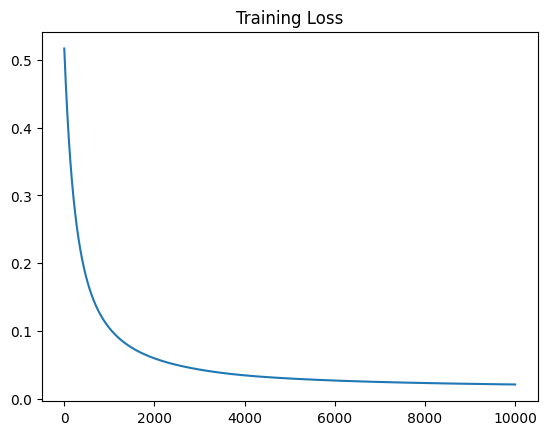

In [40]:
# 4. Train
epochs = 10000
losses = []

for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(X_tensor)
    loss = criterion(outputs, y_tensor)
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item()}")

plt.plot(losses)
plt.title("Training Loss")
plt.show()

In [41]:
# 5. Export Weights
weights = model.linear.weight.data.cpu().numpy()[0]
bias = model.linear.bias.data.cpu().numpy()[0]

print("--- Export to C++ ---")
print(f"double w_imbalance = {weights[0]};")
print(f"double w_spread = {weights[1]};")
print(f"double bias = {bias};")

--- Export to C++ ---
double w_imbalance = -0.08227860182523727;
double w_spread = 0.11006791889667511;
double bias = -4.477815628051758;
